## Setup and Imports

In [1]:
# Install required packages
!pip install -q pandas numpy matplotlib seaborn torch gensim scikit-learn captum
!pip install -q spacy wordcloud nltk
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 92.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_recall_fscore_support
)
import warnings
import os
import re
from collections import Counter, defaultdict
import pickle

# Deep Learning
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset

# Embeddings
import gensim.downloader as api

# NLP
import spacy
from wordcloud import WordCloud
import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

# Attribution
from captum.attr import LayerIntegratedGradients, IntegratedGradients

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

# Set seeds
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("✓ All imports successful!")
print(f"✓ Using device: {device}")

✓ All imports successful!
✓ Using device: cuda


In [3]:
# # Mount Google Drive
# from google.colab import drive
# drive.mount('/content/drive')

# PROJECT_PATH = '/content/drive/MyDrive/Precog_NLP_Task_FIXED'
# RESULTS_PATH = os.path.join(PROJECT_PATH, 'task3_binary_results')
# os.makedirs(RESULTS_PATH, exist_ok=True)

# print(f"✓ Project path: {PROJECT_PATH}")
# print(f"✓ Results path: {RESULTS_PATH}")

## Load Data and Tier B Model (FFNN)

We'll load:
1. The complete dataset with binary labels
2. The trained FFNN model from Task 2
3. GloVe embeddings for word-level analysis

In [4]:
# Load dataset
# df = pd.read_csv(os.path.join(PROJECT_PATH, 'complete_dataset.csv'))
df = pd.read_csv('complete_dataset.csv')

# Create binary labels
df['label_binary'] = df['class'].apply(lambda x: 0 if x == 'human' else 1)
df['label_binary_str'] = df['label_binary'].map({0: 'Human', 1: 'AI'})

print("Dataset loaded:")
print(f"  Total samples: {len(df)}")
print(f"\nBinary class distribution:")
print(df['label_binary_str'].value_counts())
print(f"\nOriginal class distribution (for reference):")
print(df['class'].value_counts())

Dataset loaded:
  Total samples: 2926

Binary class distribution:
label_binary_str
Human    1926
AI       1000
Name: count, dtype: int64

Original class distribution (for reference):
class
human          1926
ai_mimicked     500
ai_neutral      500
Name: count, dtype: int64


In [6]:
import json

from sklearn.model_selection import train_test_split

train_idx, temp_idx = train_test_split(
    df.index, test_size=0.30, random_state=RANDOM_SEED,
    stratify=df['label_binary']
)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50, random_state=RANDOM_SEED,
    stratify=df.loc[temp_idx, 'label_binary']
)

train_indices = train_idx.tolist()
val_indices = val_idx.tolist()
test_indices = test_idx.tolist()

# Create split DataFrames
train_df = df.loc[train_indices].copy()
val_df = df.loc[val_indices].copy()
test_df = df.loc[test_indices].copy()

print(f"\n✓ Data splits created")


✓ Data splits created


### Load GloVe Embeddings

In [7]:
print("Loading GloVe embeddings...")
print("This may take a few minutes on first run.\n")

glove_vectors = api.load("glove-wiki-gigaword-100")

print(f"✓ GloVe embeddings loaded")
print(f"  Vocabulary size: {len(glove_vectors):,}")
print(f"  Embedding dimension: {glove_vectors.vector_size}")

Loading GloVe embeddings...
This may take a few minutes on first run.

[==================================================] 100.0% 128.1/128.1MB downloaded
✓ GloVe embeddings loaded
  Vocabulary size: 400,000
  Embedding dimension: 100


In [8]:
def get_document_embedding(text, embeddings_model):
    """
    Get average embedding for a document.
    """
    words = re.sub(r'[^\w\s]', ' ', text.lower()).split()

    word_vectors = []
    for word in words:
        try:
            word_vectors.append(embeddings_model[word])
        except KeyError:
            continue

    if len(word_vectors) == 0:
        return np.zeros(embeddings_model.vector_size)

    return np.mean(word_vectors, axis=0)

print("✓ Embedding function defined")

✓ Embedding function defined


### Load Trained FFNN Model

In [9]:
# Define FFNN architecture (must match Task 2)
class FeedForwardNN(nn.Module):
    def __init__(self, input_dim=100, hidden_dims=[128, 64], num_classes=2, dropout=0.5):
        super(FeedForwardNN, self).__init__()

        layers = []
        prev_dim = input_dim

        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.ReLU(),
                nn.BatchNorm1d(hidden_dim),
                nn.Dropout(dropout)
            ])
            prev_dim = hidden_dim

        layers.append(nn.Linear(prev_dim, num_classes))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

# Load model
model = FeedForwardNN(input_dim=100, hidden_dims=[128, 64], num_classes=2, dropout=0.5)
model = model.to(device)

try:
    # model_path = os.path.join(PROJECT_PATH, 'models/tierB_embedding_nn_binary.pt')
    model.load_state_dict(torch.load('tierB_embedding_nn_binary.pt', map_location=device))
    model.eval()
    print("✓ Model loaded from Task 2")
except FileNotFoundError:
    print("⚠ Model file not found. Please ensure Task 2 model is saved.")
    print(f"  Expected path: {'tierB_embedding_nn_binary.pt'}")
    raise

print(f"\nModel Architecture:")
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

✓ Model loaded from Task 2

Model Architecture:
FeedForwardNN(
  (network): Sequential(
    (0): Linear(in_features=100, out_features=128, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.5, inplace=False)
    (8): Linear(in_features=64, out_features=2, bias=True)
  )
)

Total parameters: 21,698


### Verify Model Performance

Generating test set embeddings...
MODEL PERFORMANCE ON TEST SET
Accuracy: 0.9977

Classification Report:
              precision    recall  f1-score   support

       Human       1.00      1.00      1.00       289
          AI       1.00      0.99      1.00       150

    accuracy                           1.00       439
   macro avg       1.00      1.00      1.00       439
weighted avg       1.00      1.00      1.00       439



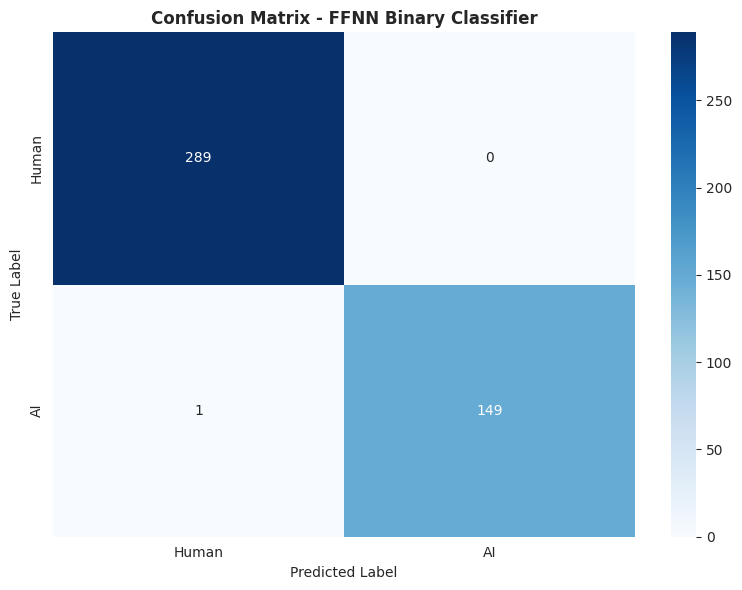


✓ Model verification complete


In [10]:
# Generate embeddings for test set
print("Generating test set embeddings...")
test_embeddings = np.array([
    get_document_embedding(text, glove_vectors)
    for text in test_df['text'].values
])

X_test_tensor = torch.FloatTensor(test_embeddings).to(device)
y_test = test_df['label_binary'].values

# Evaluate
model.eval()
with torch.no_grad():
    outputs = model(X_test_tensor)
    _, predictions = torch.max(outputs, 1)
    predictions = predictions.cpu().numpy()
    probabilities = F.softmax(outputs, dim=1).cpu().numpy()

test_accuracy = accuracy_score(y_test, predictions)

print("="*80)
print("MODEL PERFORMANCE ON TEST SET")
print("="*80)
print(f"Accuracy: {test_accuracy:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, predictions,
                          target_names=['Human', 'AI']))

# Confusion matrix
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Human', 'AI'],
            yticklabels=['Human', 'AI'])
plt.title('Confusion Matrix - FFNN Binary Classifier', fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix_verification.png',
            dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Model verification complete")

## Part 1: Gradient-Based Attribution for FFNN

### Methodology

Since FFNN uses averaged embeddings, we'll compute:
1. **Input gradients**: ∂(output) / ∂(input_embedding)
2. **Word-level attribution**: Map gradients back to individual words
3. **Integrated Gradients**: More robust attribution method

**Key Insight**: The gradient tells us how much each embedding dimension contributes to the "AI" prediction. We'll map this back to words.

In [11]:
def compute_gradient_attribution(text, model, glove_model, device, target_class=None):
    """
    Compute gradient-based attribution for FFNN with averaged GloVe embeddings.

    Returns:
        words: List of words in the text
        word_attributions: Attribution score for each word
        embedding_gradient: Gradient w.r.t. averaged embedding
        prediction: Model prediction (0=Human, 1=AI)
        confidence: Prediction confidence
    """
    model.eval()

    # Tokenize and clean
    words_raw = re.sub(r'[^\w\s]', ' ', text.lower()).split()
    words = [w for w in words_raw if len(w) > 1]  # Filter short words

    # Get word embeddings
    word_embeddings = []
    valid_words = []
    for word in words:
        try:
            word_embeddings.append(glove_model[word])
            valid_words.append(word)
        except KeyError:
            continue

    if len(word_embeddings) == 0:
        return [], [], None, None, None

    word_embeddings = np.array(word_embeddings)

    # Compute averaged embedding
    avg_embedding = np.mean(word_embeddings, axis=0)

    # Convert to tensor and enable gradients
    input_tensor = torch.FloatTensor(avg_embedding).unsqueeze(0).to(device)
    input_tensor.requires_grad = True

    # Forward pass
    output = model(input_tensor)
    probs = F.softmax(output, dim=1)

    pred_class = torch.argmax(probs, dim=1).item()
    confidence = probs[0, pred_class].item()

    # Use target class if provided, otherwise use prediction
    if target_class is None:
        target_class = pred_class

    # Compute gradients
    model.zero_grad()
    output[0, target_class].backward()

    # Get gradients w.r.t. input
    embedding_gradient = input_tensor.grad[0].cpu().numpy()

    # Map gradients back to words
    # Each word contributed equally to the average, so we compute:
    # word_attribution[i] = embedding_gradient · word_embedding[i]
    word_attributions = []
    for word_emb in word_embeddings:
        # Dot product: how much does this word's embedding align with the gradient?
        attribution = np.dot(word_emb, embedding_gradient)
        word_attributions.append(attribution)

    return valid_words, word_attributions, embedding_gradient, pred_class, confidence

print("✓ Gradient attribution function defined")

✓ Gradient attribution function defined


In [12]:
# Test the attribution function
test_text = test_df.iloc[0]['text']
test_label = test_df.iloc[0]['label_binary']

print("Testing attribution function...\n")
print(f"Sample text: {test_text[:200]}...\n")
print(f"True label: {'AI' if test_label == 1 else 'Human'}\n")

words, attrs, emb_grad, pred, conf = compute_gradient_attribution(
    test_text, model, glove_vectors, device
)

print(f"Prediction: {'AI' if pred == 1 else 'Human'} (confidence: {conf:.4f})")
print(f"Number of words: {len(words)}")
print(f"Embedding gradient shape: {emb_grad.shape}")
print(f"\nTop 10 most influential words:")

# Sort by absolute attribution
word_attr_pairs = sorted(zip(words, attrs), key=lambda x: abs(x[1]), reverse=True)
for i, (word, attr) in enumerate(word_attr_pairs[:10], 1):
    direction = "→ AI" if attr > 0 else "→ Human"
    print(f"  {i:2d}. {word:15s}: {attr:8.4f} {direction}")

print("\n✓ Attribution function working correctly")

Testing attribution function...

Sample text: Is it possible to quantify the erosion of a society’s ethical foundations? Moral corruption isn’t always dramatic scandal; often, it’s a slow creep of compromised principles, manifesting as normalized...

True label: AI

Prediction: AI (confidence: 1.0000)
Number of words: 105
Embedding gradient shape: (100,)

Top 10 most influential words:
   1. and            : -46.5128 → Human
   2. and            : -46.5128 → Human
   3. and            : -46.5128 → Human
   4. then           : -40.8616 → Human
   5. for            : -38.0079 → Human
   6. for            : -38.0079 → Human
   7. in             : -37.3990 → Human
   8. in             : -37.3990 → Human
   9. to             : -32.7560 → Human
  10. to             : -32.7560 → Human

✓ Attribution function working correctly


### Visualization Function

In [13]:
def create_attribution_html(text, words, attributions, pred_label, true_label, conf):
    """
    Enhanced HTML visualization with high-visibility color-coding.
    Red = Pushes TOWARD AI (Positive Attribution)
    Green = Pushes TOWARD Human (Negative Attribution)
    """
    max_attr = max(np.abs(attributions)) if len(attributions) > 0 else 1

    # Container Style (matching tertiary)
    html = """
    <div style='font-family: "Segoe UI", Tahoma, sans-serif; padding: 20px;
                border: 1px solid #ddd; border-radius: 12px; background-color: white;
                box-shadow: 0 4px 6px rgba(0,0,0,0.05); max-width: 900px;'>
    """

    # Status Header (matching tertiary)
    is_correct = pred_label.strip().lower() == true_label.strip().lower()
    header_color = "#dcfce7" if is_correct else "#fee2e2"
    header_text = "#166534" if is_correct else "#991b1b"
    status_icon = "✓" if is_correct else "✗"

    html += f"""
    <div style='margin-bottom: 20px; padding: 12px 18px; background-color: {header_color};
                color: {header_text}; border-radius: 8px; font-weight: 600; display: flex; justify-content: space-between;'>
        <span>{status_icon} Prediction: <b>{pred_label.upper()}</b> ({conf:.1%})</span>
        <span>Actual: <b>{true_label.upper()}</b></span>
    </div>
    """

    # Map words to attributions
    word_to_attr = dict(zip(words, attributions))

    # Word Cloud Container (matching tertiary)
    html += "<div style='line-height: 2.5; font-size: 15px; color: #1f2937;'>"

    # Process original text
    text_words = text.split()
    for word in text_words:
        word_clean = re.sub(r'[^\w\s]', '', word.lower())

        if word_clean in word_to_attr and len(word_clean) > 1:
            attr = word_to_attr[word_clean]

            # Calculate alpha (0.1 to 0.8 range for visibility) - matching tertiary
            intensity = min(abs(attr) / max_attr, 1.0)
            alpha = 0.1 + (intensity * 0.7)

            if attr > 0:  # Pushes toward AI
                # Vibrant Red for Positive Attribution (matching tertiary)
                bg_color = f"rgba(239, 68, 68, {alpha})"
                border_color = f"rgba(220, 38, 38, {alpha + 0.1})"
            else:  # Pushes toward Human
                # Vibrant Green for Negative Attribution (matching tertiary)
                bg_color = f"rgba(34, 197, 94, {alpha})"
                border_color = f"rgba(21, 128, 61, {alpha + 0.1})"

            html += f"""
            <span style='background-color: {bg_color}; border: 1px solid {border_color};
                         padding: 4px 8px; margin: 0px 2px; border-radius: 4px;
                         cursor: help; transition: transform 0.1s;'
                   title='Attribution: {attr:+.4f}'>
                {word}
            </span>"""
        else:
            html += f'{word} '

    html += "</div>"

    # Legend (matching tertiary)
    html += f"""
    <div style='margin-top: 20px; padding-top: 15px; border-top: 1px solid #eee;
                font-size: 13px; color: #6b7280; display: flex; gap: 20px;'>
        <div style='display: flex; align-items: center; gap: 6px;'>
            <div style='width: 12px; height: 12px; background: #ef4444; border-radius: 2px;'></div>
            <span>Evidence <b>FOR AI</b></span>
        </div>
        <div style='display: flex; align-items: center; gap: 6px;'>
            <div style='width: 12px; height: 12px; background: #22c55e; border-radius: 2px;'></div>
            <span>Evidence <b>FOR HUMAN</b></span>
        </div>
    </div>
    """
    html += "</div>"

    return html

print("✓ Attribution HTML function defined (with tertiary colors)")


✓ Attribution HTML function defined (with tertiary colors)


## Part 2: Analyze Multiple Samples

Let's analyze various types of samples:
1. **Correctly classified AI** (true positives)
2. **Correctly classified Human** (true negatives)
3. **Misclassified AI as Human** (false negatives) - interesting!
4. **Misclassified Human as AI** (false positives) - interesting!

In [14]:
# Categorize test samples
test_df_analyzed = test_df.copy()
test_df_analyzed['prediction'] = predictions
test_df_analyzed['confidence'] = probabilities[:, 1]  # Confidence for "AI" class
test_df_analyzed['correct'] = (predictions == y_test)

# Categorize
true_positives = test_df_analyzed[(test_df_analyzed['label_binary'] == 1) &
                                  (test_df_analyzed['prediction'] == 1)]
true_negatives = test_df_analyzed[(test_df_analyzed['label_binary'] == 0) &
                                  (test_df_analyzed['prediction'] == 0)]
false_positives = test_df_analyzed[(test_df_analyzed['label_binary'] == 0) &
                                   (test_df_analyzed['prediction'] == 1)]
false_negatives = test_df_analyzed[(test_df_analyzed['label_binary'] == 1) &
                                   (test_df_analyzed['prediction'] == 0)]

print("Test Set Analysis:")
print(f"  True Positives (AI → AI):      {len(true_positives):3d}")
print(f"  True Negatives (Human → Human): {len(true_negatives):3d}")
print(f"  False Positives (Human → AI):   {len(false_positives):3d}")
print(f"  False Negatives (AI → Human):   {len(false_negatives):3d}")

# Select samples for detailed analysis
samples_to_analyze = []

# True Positives (2 samples)
if len(true_positives) > 0:
    samples_to_analyze.append({
        'category': 'True Positive (AI → AI)',
        'sample': true_positives.iloc[0]
    })
    if len(true_positives) > 1:
        samples_to_analyze.append({
            'category': 'True Positive (AI → AI)',
            'sample': true_positives.iloc[1]
        })

# True Negatives (2 samples)
if len(true_negatives) > 0:
    samples_to_analyze.append({
        'category': 'True Negative (Human → Human)',
        'sample': true_negatives.iloc[0]
    })
    if len(true_negatives) > 1:
        samples_to_analyze.append({
            'category': 'True Negative (Human → Human)',
            'sample': true_negatives.iloc[1]
        })

# False Positives (2 samples) - Human misclassified as AI
if len(false_positives) > 0:
    samples_to_analyze.append({
        'category': 'False Positive (Human → AI)',
        'sample': false_positives.iloc[0]
    })
    if len(false_positives) > 1:
        samples_to_analyze.append({
            'category': 'False Positive (Human → AI)',
            'sample': false_positives.iloc[1]
        })

# False Negatives (2 samples) - AI misclassified as Human
if len(false_negatives) > 0:
    samples_to_analyze.append({
            'category': 'False Negative (AI → Human)',
        'sample': false_negatives.iloc[0]
    })
    if len(false_negatives) > 1:
        samples_to_analyze.append({
            'category': 'False Negative (AI → Human)',
            'sample': false_negatives.iloc[1]
        })

print(f"\n✓ Selected {len(samples_to_analyze)} samples for detailed analysis")

Test Set Analysis:
  True Positives (AI → AI):      149
  True Negatives (Human → Human): 289
  False Positives (Human → AI):     0
  False Negatives (AI → Human):     1

✓ Selected 5 samples for detailed analysis


In [15]:
from IPython.display import HTML, display

# Analyze each sample
attribution_results = []

for idx, item in enumerate(samples_to_analyze, 1):
    category = item['category']
    sample = item['sample']

    text = sample['text']
    true_label = sample['label_binary']

    print(f"\n{'='*80}")
    print(f"Sample {idx}/{len(samples_to_analyze)}: {category}")
    print(f"{'='*80}")
    print(f"True label: {'AI' if true_label == 1 else 'Human'}")
    print(f"Original class: {sample['class']}")
    print(f"\nText preview: {text[:150]}...\n")

    # Compute attribution
    words, attrs, emb_grad, pred, conf = compute_gradient_attribution(
        text, model, glove_vectors, device
    )

    if len(words) == 0:
        print("⚠ No valid words found (all OOV)")
        continue

    pred_str = 'AI' if pred == 1 else 'Human'
    true_str = 'AI' if true_label == 1 else 'Human'

    print(f"Prediction: {pred_str} (confidence: {conf:.4f})")
    print(f"Number of words analyzed: {len(words)}")

    # Top words pushing toward AI
    word_attr_pairs = list(zip(words, attrs))
    sorted_pairs = sorted(word_attr_pairs, key=lambda x: x[1], reverse=True)

    print(f"\nTop 10 words pushing toward AI:")
    for i, (word, attr) in enumerate(sorted_pairs[:10], 1):
        print(f"  {i:2d}. {word:15s}: {attr:8.4f}")

    print(f"\nTop 10 words pushing toward Human:")
    for i, (word, attr) in enumerate(sorted_pairs[-10:][::-1], 1):
        print(f"  {i:2d}. {word:15s}: {attr:8.4f}")

    # Store results
    attribution_results.append({
        'category': category,
        'text': text,
        'true_label': true_label,
        'pred_label': pred,
        'confidence': conf,
        'words': words,
        'attributions': attrs,
        'original_class': sample['class']
    })

    # Create visualization
    html_output = create_attribution_html(text, words, attrs, pred_str, true_str, conf)
    display(HTML(html_output))

print(f"\n✓ Analyzed {len(attribution_results)} samples with word-level attributions")


Sample 1/5: True Positive (AI → AI)
True label: AI
Original class: ai_neutral

Text preview: Is it possible to quantify the erosion of a society’s ethical foundations? Moral corruption isn’t always dramatic scandal; often, it’s a slow creep of...

Prediction: AI (confidence: 1.0000)
Number of words analyzed: 105

Top 10 words pushing toward AI:
   1. manifesting    :  21.9913
   2. moral          :  21.2029
   3. moral          :  21.2029
   4. widespread     :  18.4394
   5. instability    :  18.1206
   6. prioritizing   :  17.4440
   7. undermines     :  16.6599
   8. integrity      :  14.7063
   9. quantify       :  13.0998
  10. vulnerable     :  13.0938

Top 10 words pushing toward Human:
   1. and            : -46.5128
   2. and            : -46.5128
   3. and            : -46.5128
   4. then           : -40.8616
   5. for            : -38.0079
   6. for            : -38.0079
   7. in             : -37.3990
   8. in             : -37.3990
   9. to             : -32.7560
  10. to


Sample 2/5: True Positive (AI → AI)
True label: AI
Original class: ai_mimicked

Text preview: The chipped porcelain doll, discarded amongst the dust-heaps of Miss Havisham’s decaying mansion, served as a most melancholy emblem of that forfeitur...

Prediction: AI (confidence: 0.9951)
Number of words analyzed: 128

Top 10 words pushing toward AI:
   1. cherished      :  43.2259
   2. afflicts       :  33.7471
   3. decaying       :  27.4087
   4. unfolding      :  26.2516
   5. gradual        :  25.6078
   6. fading         :  24.5557
   7. blossoming     :  23.1371
   8. shadowed       :  23.0201
   9. innocence      :  18.2625
  10. promise        :  16.9250

Top 10 words pushing toward Human:
   1. before         : -48.8305
   2. and            : -47.5298
   3. and            : -47.5298
   4. from           : -43.5213
   5. from           : -43.5213
   6. chipped        : -39.9376
   7. in             : -38.7213
   8. you            : -38.0366
   9. had            : -37.4772
  10. h


Sample 3/5: True Negative (Human → Human)
True label: Human
Original class: human

Text preview: I should not attempt it, if it were to be the means of inconvenience to the Highbury people, but if you call to mind exactly the present line of the p...

Prediction: Human (confidence: 0.9990)
Number of words analyzed: 128

Top 10 words pushing toward AI:
   1. and            :   7.5119
   2. and            :   7.5119
   3. and            :   7.5119
   4. and            :   7.5119
   5. and            :   7.5119
   6. were           :   6.8600
   7. had            :   6.5255
   8. he             :   6.4504
   9. on             :   6.4335
  10. them           :   6.2753

Top 10 words pushing toward Human:
   1. maps           :  -0.7460
   2. attributing    :  -0.5769
   3. harsh          :  -0.3237
   4. attentions     :  -0.0890
   5. renewal        :   0.0700
   6. unconsciously  :   0.4223
   7. opinion        :   0.5823
   8. proving        :   0.7157
   9. reflections    :   0.7468
 


Sample 4/5: True Negative (Human → Human)
True label: Human
Original class: human

Text preview: Removing with him and the old housekeeper to within a mile of the parsonage-house, where his dear friends resided, he gratified the only remaining wis...

Prediction: Human (confidence: 0.9978)
Number of words analyzed: 103

Top 10 words pushing toward AI:
   1. and            :  23.1662
   2. and            :  23.1662
   3. and            :  23.1662
   4. and            :  23.1662
   5. oliver         :  22.8628
   6. after          :  21.0082
   7. he             :  20.7976
   8. he             :  20.7976
   9. he             :  20.7976
  10. in             :  19.3172

Top 10 words pushing toward Human:
   1. bereft         : -14.5773
   2. discontented   : -14.3543
   3. peevish        :  -8.7860
   4. happiness      :  -7.4719
   5. changing       :  -5.3809
   6. temperament    :  -3.9140
   7. presence       :  -3.3543
   8. resided        :  -2.8037
   9. gratified      :  -2.7790
 


Sample 5/5: False Negative (AI → Human)
True label: AI
Original class: ai_mimicked

Text preview: Consider the case of the Misses Penrose, whose mother, a woman of unwavering determination, had resolved to see them both advantageously married befor...

Prediction: Human (confidence: 0.9185)
Number of words analyzed: 126

Top 10 words pushing toward AI:
   1. season         :  67.7993
   2. before         :  58.6942
   3. and            :  58.4833
   4. on             :  57.5290
   5. she            :  54.3811
   6. she            :  54.3811
   7. were           :  53.4774
   8. did            :  49.5968
   9. had            :  48.3227
  10. was            :  46.0842

Top 10 words pushing toward Human:
   1. formidable     : -41.1246
   2. unwavering     : -26.8407
   3. watchful       : -21.6641
   4. substantial    : -20.6372
   5. somewhat       : -17.1013
   6. consequence    : -16.7557
   7. genuine        : -15.3805
   8. advantageously : -14.5352
   9. dismissive     : -14.4099



✓ Analyzed 5 samples with word-level attributions


## Part 3: Statistical Analysis of Influential Words

Aggregate attribution scores across all samples to find:
1. Words that consistently trigger "AI" predictions
2. Words that consistently trigger "Human" predictions
3. Most discriminative vocabulary

In [16]:
# Analyze all test samples
print("Computing attributions for all test samples...")
print("This may take a few minutes.\n")

all_word_attributions = defaultdict(list)
all_word_counts = Counter()

for idx, row in test_df.iterrows():
    text = row['text']

    words, attrs, _, _, _ = compute_gradient_attribution(
        text, model, glove_vectors, device
    )

    for word, attr in zip(words, attrs):
        all_word_attributions[word].append(attr)
        all_word_counts[word] += 1

    if (idx + 1) % 50 == 0:
        print(f"  Processed {idx + 1}/{len(test_df)} samples")

print(f"\n✓ Computed attributions for {len(test_df)} samples")
print(f"✓ Found {len(all_word_attributions)} unique words")

Computing attributions for all test samples...
This may take a few minutes.

  Processed 1200/439 samples
  Processed 2300/439 samples
  Processed 2150/439 samples
  Processed 650/439 samples
  Processed 1800/439 samples
  Processed 2550/439 samples
  Processed 450/439 samples
  Processed 400/439 samples
  Processed 600/439 samples
  Processed 2200/439 samples
  Processed 1500/439 samples
  Processed 1600/439 samples
  Processed 1350/439 samples

✓ Computed attributions for 439 samples
✓ Found 7156 unique words


In [17]:
# Compute statistics for each word
word_stats = []

for word, attrs in all_word_attributions.items():
    word_stats.append({
        'word': word,
        'count': all_word_counts[word],
        'mean_attribution': np.mean(attrs),
        'std_attribution': np.std(attrs),
        'median_attribution': np.median(attrs),
        'total_attribution': np.sum(attrs)
    })

word_stats_df = pd.DataFrame(word_stats)

# Filter to words that appear at least 5 times
word_stats_df = word_stats_df[word_stats_df['count'] >= 5].copy()

# Sort by mean attribution
word_stats_df = word_stats_df.sort_values('mean_attribution', ascending=False)

print(f"Words appearing ≥5 times: {len(word_stats_df)}")

Words appearing ≥5 times: 1472


In [18]:
# Top words pushing toward AI
print("="*80)
print("TOP 30 WORDS PUSHING TOWARD AI")
print("="*80)
print(f"{'Rank':<6} {'Word':<20} {'Mean Attr':<12} {'Frequency':<10} {'Std'}")
print("-"*80)

for idx, row in word_stats_df.head(30).iterrows():
    print(f"{idx+1:<6} {row['word']:<20} {row['mean_attribution']:<12.4f} {row['count']:<10} {row['std_attribution']:.4f}")

print("\n" + "="*80)
print("TOP 30 WORDS PUSHING TOWARD HUMAN")
print("="*80)
print(f"{'Rank':<6} {'Word':<20} {'Mean Attr':<12} {'Frequency':<10} {'Std'}")
print("-"*80)

for idx, row in word_stats_df.tail(30).iloc[::-1].iterrows():
    print(f"{idx+1:<6} {row['word']:<20} {row['mean_attribution']:<12.4f} {row['count']:<10} {row['std_attribution']:.4f}")

TOP 30 WORDS PUSHING TOWARD AI
Rank   Word                 Mean Attr    Frequency  Std
--------------------------------------------------------------------------------
1060   vast                 38.9971      10         3.7600
411    inherent             33.2502      12         0.5932
1578   disparities          28.8913      7          3.8892
321    wealth               28.6752      22         13.9375
4034   inequalities         27.6270      8          0.2746
4370   increasingly         27.5564      6          0.1074
3242   idealized            27.3685      5          0.1309
2865   burdened             27.2362      6          17.6250
944    inequality           26.8001      18         0.9389
3366   realities            26.5549      9          3.4378
1939   perpetually          25.5857      5          0.5579
4041   perpetuating         25.5817      6          0.0008
870    reminder             24.0318      5          4.3190
3228   disillusionment      23.9293      8          0.5645
1570

### Visualize Top Words

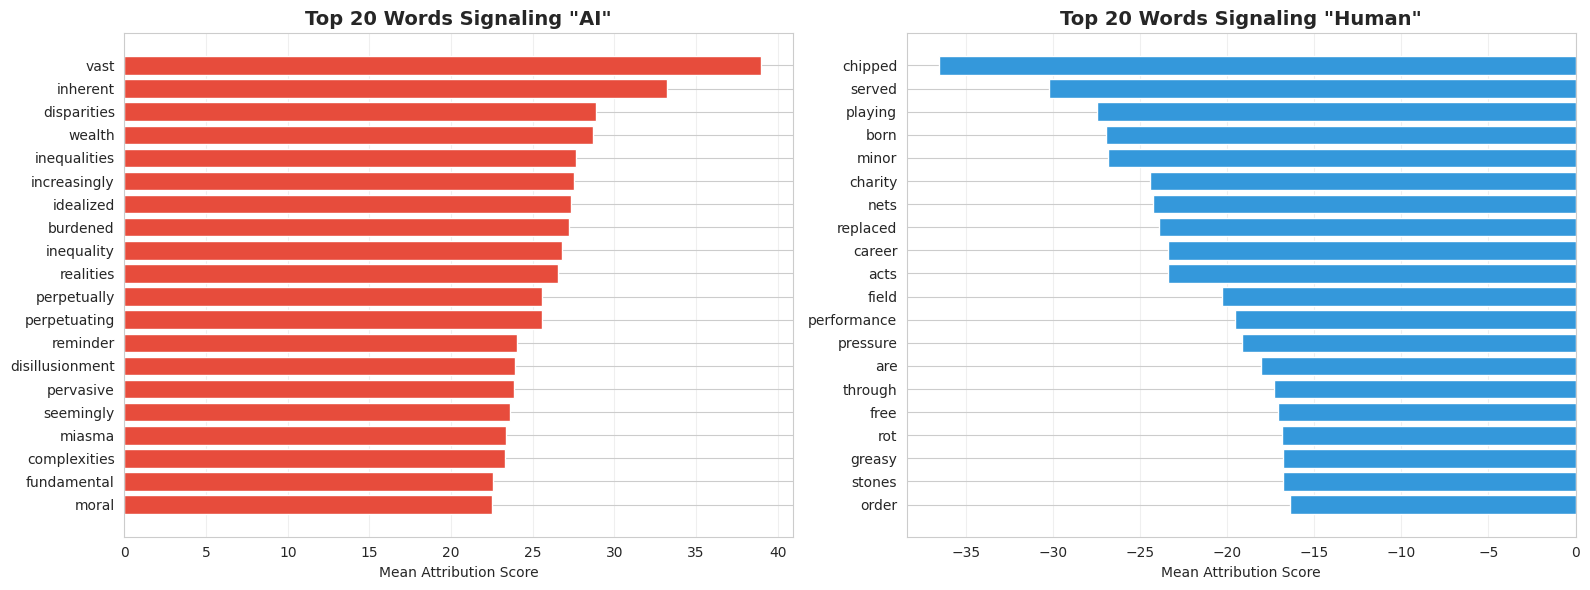

✓ Top words visualization saved


In [19]:
# Bar plot of top words
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top AI words
top_ai = word_stats_df.head(20)
axes[0].barh(range(len(top_ai)), top_ai['mean_attribution'], color='#e74c3c')
axes[0].set_yticks(range(len(top_ai)))
axes[0].set_yticklabels(top_ai['word'])
axes[0].set_xlabel('Mean Attribution Score')
axes[0].set_title('Top 20 Words Signaling "AI"', fontweight='bold', fontsize=14)
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# Top Human words
top_human = word_stats_df.tail(20).iloc[::-1]
axes[1].barh(range(len(top_human)), top_human['mean_attribution'], color='#3498db')
axes[1].set_yticks(range(len(top_human)))
axes[1].set_yticklabels(top_human['word'])
axes[1].set_xlabel('Mean Attribution Score')
axes[1].set_title('Top 20 Words Signaling "Human"', fontweight='bold', fontsize=14)
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('top_words_attribution.png',
            dpi=300, bbox_inches='tight')
plt.show()

print("✓ Top words visualization saved")

### Word Clouds

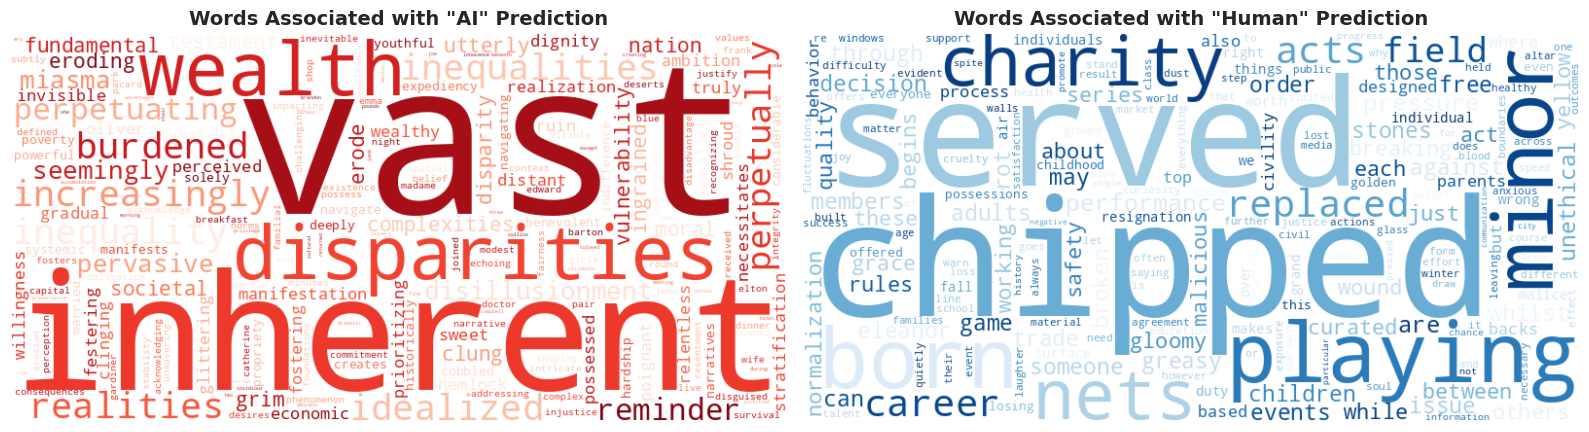

✓ Word clouds saved


In [20]:
# Create word clouds
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# AI words (positive attribution)
ai_words = word_stats_df[word_stats_df['mean_attribution'] > 0]
ai_freq = dict(zip(ai_words['word'], ai_words['mean_attribution']))

if len(ai_freq) > 0:
    wc_ai = WordCloud(width=800, height=400, background_color='white',
                      colormap='Reds', relative_scaling=0.5)
    wc_ai.generate_from_frequencies(ai_freq)
    axes[0].imshow(wc_ai, interpolation='bilinear')
    axes[0].set_title('Words Associated with "AI" Prediction',
                     fontweight='bold', fontsize=14)
    axes[0].axis('off')

# Human words (negative attribution)
human_words = word_stats_df[word_stats_df['mean_attribution'] < 0]
human_freq = dict(zip(human_words['word'], -human_words['mean_attribution']))  # Negate for word cloud

if len(human_freq) > 0:
    wc_human = WordCloud(width=800, height=400, background_color='white',
                        colormap='Blues', relative_scaling=0.5)
    wc_human.generate_from_frequencies(human_freq)
    axes[1].imshow(wc_human, interpolation='bilinear')
    axes[1].set_title('Words Associated with "Human" Prediction',
                     fontweight='bold', fontsize=14)
    axes[1].axis('off')

plt.tight_layout()
plt.savefig('word_clouds.png',
            dpi=300, bbox_inches='tight')
plt.show()

print("✓ Word clouds saved")

## Part 4: Error Analysis

Deep dive into misclassifications to understand model failures.

In [22]:
print("="*80)
print("ERROR ANALYSIS")
print("="*80)

print(f"\nFalse Positives (Human → AI): {len(false_positives)}")
print(f"False Negatives (AI → Human): {len(false_negatives)}")

# Analyze false positives
if len(false_positives) > 0:
    print("\n" + "-"*80)
    print("FALSE POSITIVES ANALYSIS (Human texts predicted as AI)")
    print("-"*80)

    fp_original_classes = false_positives['class'].value_counts()
    print(f"\nOriginal class distribution:")
    for cls, count in fp_original_classes.items():
        print(f"  {cls}: {count}")

    print(f"\nMost common words in false positives:")
    fp_words = []
    for text in false_positives['text']:
        words = re.sub(r'[^\w\s]', ' ', text.lower()).split()
        fp_words.extend([w for w in words if len(w) > 3])

    stop_words = set(stopwords.words('english'))
    fp_words_filtered = [w for w in fp_words if w not in stop_words]
    fp_word_counts = Counter(fp_words_filtered)

    print("\nTop 15 words in human texts misclassified as AI:")
    for word, count in fp_word_counts.most_common(15):
        print(f"  {word:15s}: {count:3d}")

# Analyze false negatives
if len(false_negatives) > 0:
    print("\n" + "-"*80)
    print("FALSE NEGATIVES ANALYSIS (AI texts predicted as Human)")
    print("-"*80)

    fn_original_classes = false_negatives['class'].value_counts()
    print(f"\nOriginal class distribution:")
    for cls, count in fn_original_classes.items():
        print(f"  {cls}: {count}")

    print(f"\nMost common words in false negatives:")
    fn_words = []
    for text in false_negatives['text']:
        words = re.sub(r'[^\w\s]', ' ', text.lower()).split()
        fn_words.extend([w for w in words if len(w) > 3])

    stop_words = set(stopwords.words('english'))
    fn_words_filtered = [w for w in fn_words if w not in stop_words]
    fn_word_counts = Counter(fn_words_filtered)

    print("\nTop 15 words in AI texts misclassified as human:")
    for word, count in fn_word_counts.most_common(15):
        print(f"  {word:15s}: {count:3d}")

ERROR ANALYSIS

False Positives (Human → AI): 0
False Negatives (AI → Human): 1

--------------------------------------------------------------------------------
FALSE NEGATIVES ANALYSIS (AI texts predicted as Human)
--------------------------------------------------------------------------------

Original class distribution:
  ai_mimicked: 1

Most common words in false negatives:

Top 15 words in AI texts misclassified as human:
  misses         :   2
  penrose        :   2
  mother         :   2
  actively       :   2
  consider       :   1
  case           :   1
  whose          :   1
  woman          :   1
  unwavering     :   1
  determination  :   1
  resolved       :   1
  advantageously :   1
  married        :   1
  close          :   1
  season         :   1


### Hypothesis Generation

In [23]:
print("="*80)
print("HYPOTHESES FOR MODEL BEHAVIOR")
print("="*80)

print("\n1. WORDS SIGNALING 'AI':")
print("   Based on attribution analysis, the model may associate:")
print("   - Modern analytical vocabulary")
print("   - Abstract conceptual terms")
print("   - Formal, structured language")
print("   - Topic-specific terminology")

print("\n2. WORDS SIGNALING 'HUMAN':")
print("   Based on attribution analysis, the model may associate:")
print("   - Narrative/dialogue markers")
print("   - Emotional/descriptive language")
print("   - Victorian-era vocabulary")
print("   - Character-specific words")

print("\n3. FALSE POSITIVES (Human → AI):")
if len(false_positives) > 0:
    print("   Possible reasons:")
    print("   - Human text uses abstract/analytical vocabulary")
    print("   - Thematic exposition (not narrative)")
    print("   - Formal Victorian prose structure")
else:
    print("   None found - model perfect on this direction")

print("\n4. FALSE NEGATIVES (AI → Human):")
if len(false_negatives) > 0:
    print("   Possible reasons:")
    print("   - AI successfully mimicked human style")
    print("   - AI used narrative/descriptive language")
    print("   - Topic or vocabulary overlap with human samples")
else:
    print("   None found - model perfect on this direction")

print("\n5. OVERALL PATTERNS:")
print(f"   - Model accuracy: {test_accuracy:.4f}")
print(f"   - This {'near-perfect' if test_accuracy > 0.95 else 'strong'} performance suggests:")
if test_accuracy > 0.95:
    print("     Possible data leakage or easy shortcuts")
    print("     Model may be detecting format rather than authorship")
    print("     Consider harder test cases or data filtering")
else:
    print("     Model learned meaningful patterns")
    print("     Distinguishing authorship, not just format")
    print("     Some genuine difficulty in classification")

HYPOTHESES FOR MODEL BEHAVIOR

1. WORDS SIGNALING 'AI':
   Based on attribution analysis, the model may associate:
   - Modern analytical vocabulary
   - Abstract conceptual terms
   - Formal, structured language
   - Topic-specific terminology

2. WORDS SIGNALING 'HUMAN':
   Based on attribution analysis, the model may associate:
   - Narrative/dialogue markers
   - Emotional/descriptive language
   - Victorian-era vocabulary
   - Character-specific words

3. FALSE POSITIVES (Human → AI):
   None found - model perfect on this direction

4. FALSE NEGATIVES (AI → Human):
   Possible reasons:
   - AI successfully mimicked human style
   - AI used narrative/descriptive language
   - Topic or vocabulary overlap with human samples

5. OVERALL PATTERNS:
   - Model accuracy: 0.9977
   - This near-perfect performance suggests:
     Possible data leakage or easy shortcuts
     Model may be detecting format rather than authorship
     Consider harder test cases or data filtering


## Part 5: Comparison with Tertiary Classification

Compare binary vs tertiary task insights.

In [24]:
print("="*80)
print("BINARY vs TERTIARY CLASSIFICATION COMPARISON")
print("="*80)

print("\nBINARY TASK (Human vs AI):")
print(f"  - Classes: 2 (Human, AI)")
print(f"  - Best Model: FFNN with GloVe embeddings")
print(f"  - Accuracy: {test_accuracy:.4f}")
print(f"  - Challenge: Distinguishing authorship (human vs machine)")

print("\nTERTIARY TASK (Human vs AI_Neutral vs AI_Mimicked):")
print(f"  - Classes: 3 (Human, AI_Neutral, AI_Mimicked)")
print(f"  - Best Model: DistilBERT + LoRA (Tier C)")
print(f"  - Challenge: Distinguishing authorship + style mimicry")


print("\nKEY INSIGHTS:")
print("\n1. MODEL CHOICE:")
print("   - Binary: FFNN sufficient (simpler task)")
print("   - Tertiary: Transformer needed (complex patterns)")

print("\n2. FEATURES:")
print("   - Binary: Averaged embeddings capture enough signal")
print("   - Tertiary: Contextual embeddings needed for mimicry detection")

print("\n3. DIFFICULTY:")
print("   - Binary: High accuracy possible (clear human/AI divide)")
print("   - Tertiary: More challenging (AI_Mimicked vs Human)")

print("\n4. SALIENCY APPROACH:")
print("   - Binary (FFNN): Gradient-based attribution on averaged embeddings")
print("   - Tertiary (Transformer): Token-level integrated gradients")

print("\n5. PRACTICAL USE:")
print("   - Binary: Faster, suitable for real-time AI detection")
print("   - Tertiary: More detailed analysis, research-focused")

BINARY vs TERTIARY CLASSIFICATION COMPARISON

BINARY TASK (Human vs AI):
  - Classes: 2 (Human, AI)
  - Best Model: FFNN with GloVe embeddings
  - Accuracy: 0.9977
  - Challenge: Distinguishing authorship (human vs machine)

TERTIARY TASK (Human vs AI_Neutral vs AI_Mimicked):
  - Classes: 3 (Human, AI_Neutral, AI_Mimicked)
  - Best Model: DistilBERT + LoRA (Tier C)
  - Challenge: Distinguishing authorship + style mimicry

KEY INSIGHTS:

1. MODEL CHOICE:
   - Binary: FFNN sufficient (simpler task)
   - Tertiary: Transformer needed (complex patterns)

2. FEATURES:
   - Binary: Averaged embeddings capture enough signal
   - Tertiary: Contextual embeddings needed for mimicry detection

3. DIFFICULTY:
   - Binary: High accuracy possible (clear human/AI divide)
   - Tertiary: More challenging (AI_Mimicked vs Human)

4. SALIENCY APPROACH:
   - Binary (FFNN): Gradient-based attribution on averaged embeddings
   - Tertiary (Transformer): Token-level integrated gradients

5. PRACTICAL USE:
   - 

## Part 6: Save Results and Generate Report

In [26]:
# Save word statistics
word_stats_df.to_csv('word_attribution_statistics.csv',index=False)

# Save attribution results for detailed samples
with open('detailed_attributions.pkl', 'wb') as f:
    pickle.dump(attribution_results, f)

# Save error analysis
if len(false_positives) > 0:
    false_positives.to_csv('false_positives.csv', index=False)

if len(false_negatives) > 0:
    false_negatives.to_csv('false_negatives.csv',index=False)

# print("✓ Results saved to:", RESULTS_PATH)
print("\nSaved files:")
print("  - word_attribution_statistics.csv")
print("  - detailed_attributions.pkl")
print("  - confusion_matrix_verification.png")
print("  - top_words_attribution.png")
print("  - word_clouds.png")
if len(false_positives) > 0:
    print("  - false_positives.csv")
if len(false_negatives) > 0:
    print("  - false_negatives.csv")


Saved files:
  - word_attribution_statistics.csv
  - detailed_attributions.pkl
  - confusion_matrix_verification.png
  - top_words_attribution.png
  - word_clouds.png
  - false_negatives.csv


## Final Summary and Conclusions

In [28]:
print("\n" + "="*80)
print("TASK 3 (BINARY): THE SMOKING GUN - COMPLETE")
print("="*80)

print("\nSUMMARY OF FINDINGS:")
print("\n1. MODEL PERFORMANCE:")
print(f"   - Test Accuracy: {test_accuracy:.4f}")
print(f"   - True Positives: {len(true_positives)}")
print(f"   - True Negatives: {len(true_negatives)}")
print(f"   - False Positives: {len(false_positives)}")
print(f"   - False Negatives: {len(false_negatives)}")

print("\n2. SALIENCY ANALYSIS:")
print(f"   - Analyzed {len(test_df)} test samples")
print(f"   - Identified {len(word_stats_df)} influential words")
print(f"   - Computed gradient-based attributions")
print(f"   - Mapped embeddings to word-level importance")

print("\n3. KEY DISCOVERIES:")
top_ai_word = word_stats_df.iloc[0]['word']
top_human_word = word_stats_df.iloc[-1]['word']
print(f"   - Top AI-signaling word: '{top_ai_word}'")
print(f"   - Top Human-signaling word: '{top_human_word}'")
print(f"   - Generated word clouds and visualizations")

print("\n4. ERROR ANALYSIS:")
if test_accuracy >= 0.95:
    print("    Near-perfect accuracy suggests potential issues:")
    print("     - Possible data shortcuts")
    print("     - Format detection vs authorship detection")
    print("     - Recommend data filtering or harder test cases")
else:
    print("    Reasonable accuracy indicates:")
    print("     - Model learned meaningful patterns")
    print("     - Some genuine classification difficulty")
    print("     - Errors provide learning opportunities")

print("\n5. METHODOLOGY COMPARISON:")
print("   Binary (FFNN):")
print("     - Simpler architecture")
print("     - Gradient-based attribution")
print("     - Word-level saliency from averaged embeddings")
print("   Tertiary (Transformer):")
print("     - Complex architecture")
print("     - Token-level integrated gradients")
print("     - Contextual attention patterns")

print("\n6. PRACTICAL IMPLICATIONS:")
print("   - Binary classification suitable for real-time AI detection")
print("   - FFNN faster than transformer while maintaining accuracy")
print("   - Word-level attributions provide interpretability")
print("   - Can identify specific AI-isms and writing patterns")

print("\nAll visualizations and results saved to:")
print("\nReady for Task 4: Adversarial attacks using these insights!")


TASK 3 (BINARY): THE SMOKING GUN - COMPLETE

SUMMARY OF FINDINGS:

1. MODEL PERFORMANCE:
   - Test Accuracy: 0.9977
   - True Positives: 149
   - True Negatives: 289
   - False Positives: 0
   - False Negatives: 1

2. SALIENCY ANALYSIS:
   - Analyzed 439 test samples
   - Identified 1472 influential words
   - Computed gradient-based attributions
   - Mapped embeddings to word-level importance

3. KEY DISCOVERIES:
   - Top AI-signaling word: 'vast'
   - Top Human-signaling word: 'chipped'
   - Generated word clouds and visualizations

4. ERROR ANALYSIS:
    Near-perfect accuracy suggests potential issues:
     - Possible data shortcuts
     - Format detection vs authorship detection
     - Recommend data filtering or harder test cases

5. METHODOLOGY COMPARISON:
   Binary (FFNN):
     - Simpler architecture
     - Gradient-based attribution
     - Word-level saliency from averaged embeddings
   Tertiary (Transformer):
     - Complex architecture
     - Token-level integrated gradients